# 03 — Cosmic-ray module

Fit the all-particle reference with a triple-broken power law and score for GZK-violating tails.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from anomalymetric.cosmicray.spectrum import cr_allparticle_grid, cr_reference_dnde, make_cr_spectrum
from anomalymetric.cosmicray.score import cr_score
from anomalymetric.cosmicray.knee_ankle import TripleBrokenPowerLaw
from anomalymetric.models.inference import Fit

edges = cr_allparticle_grid(9, 21, 10)
centers = 0.5 * (edges[:-1] + edges[1:])
dnde_ref = cr_reference_dnde(centers)
widths = np.diff(10.**edges)
exposure = np.full_like(widths, 1e10)
expected = dnde_ref * widths * exposure
rng = np.random.default_rng(0)
counts = rng.poisson(np.clip(expected, 0, None)).astype(float)
spec = make_cr_spectrum(edges, counts, exposure)
print('CR spectrum bins:', spec.n_bins)

CR spectrum bins: 120


In [2]:
model = TripleBrokenPowerLaw()
res = Fit(model, spec).run()
print('log L =', res.log_likelihood)
for k, v in res.parameter_values.items():
    print(f'  {k} = {v:.4g}')

log L = -64481012417912.07
  amplitude = 5.487e-10
  index_lo = 5
  index_mid = 0.17
  index_hi = 0
  index_gzk = 20
  E_knee_eV = 1e+12
  E_ankle_eV = 1e+16
  E_gzk_eV = 1e+18
  reference_eV = 1e+12
  smoothness = 5


In [3]:
score = cr_score(spec)
print('TS=%.2f anomaly_score=%.2f best=%s' % (score.test_statistic, score.anomaly_score, score.best_template))

TS=1.10 anomaly_score=0.33 best=hardcut.CR_1EeV


Text(0.5, 1.0, 'All-particle CR spectrum')

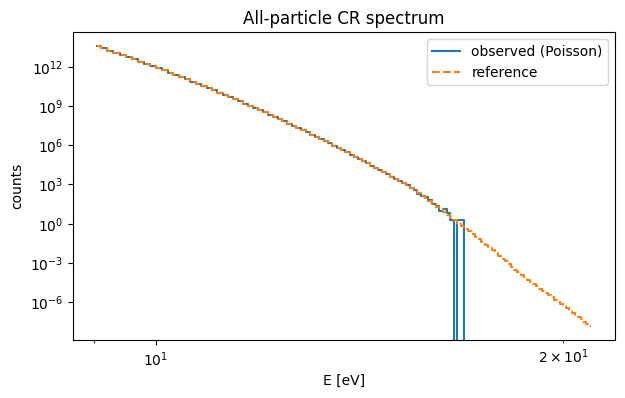

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
ax.step(centers, counts, where='mid', label='observed (Poisson)')
ax.step(centers, expected, where='mid', linestyle='--', label='reference')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('E [eV]'); ax.set_ylabel('counts')
ax.legend(); ax.set_title('All-particle CR spectrum')